# Лабораторная работа №1
### Выполнила студентка группы М092501(70) Пьянова Анна

### Задания на лабораторную работу
- Поиск датасета на платформе Kaggle
- Формулировка гипотезы
- Построение матрицы корреляции

### Выполнение работы

**Ссылка на датасет**: https://www.kaggle.com/datasets/beridzeg45/runners-dataset

**Гипотеза**: если результат в беге на 100 метров у мужчин улучшился, то и на дистанции 200 метров показатель будет лучше

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

Загрузка датасета

In [28]:
df = pd.read_csv('runners.csv')
print(df.head())
print(df.info())

   Discipline Gender       Runner  Time Country        Date
0  100 metres    men   Usain Bolt  9.58     JAM  2009-08-16
1  100 metres    men   Usain Bolt  9.63     JAM  2012-08-05
2  100 metres    men   Usain Bolt  9.69     JAM  2008-08-16
3  100 metres    men    Tyson Gay  9.69     USA  2009-09-20
4  100 metres    men  Yohan Blake  9.69     JAM  2012-08-23
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67949 entries, 0 to 67948
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Discipline  67949 non-null  object 
 1   Gender      67949 non-null  object 
 2   Runner      67949 non-null  object 
 3   Time        67949 non-null  float64
 4   Country     67949 non-null  object 
 5   Date        67560 non-null  object 
dtypes: float64(1), object(5)
memory usage: 3.1+ MB
None


Предобработка данных

In [ ]:
df_clean = df.copy()

# Удаление неиспользуемых столбцов
df_clean = df_clean.drop(['Runner', 'Country'], axis=1)

# Преобразование даты в datetime
df_clean['Date'] = pd.to_datetime(df_clean['Date'])
df_clean['Year'] = df_clean['Date'].dt.year

# Удаление строк с пропущенными значениями
df_clean.dropna(inplace=True)

df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 67560 entries, 0 to 67948
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Discipline  67560 non-null  object        
 1   Gender      67560 non-null  object        
 2   Time        67560 non-null  float64       
 3   Date        67560 non-null  datetime64[ns]
 4   Year        67560 non-null  float64       
dtypes: datetime64[ns](1), float64(2), object(2)
memory usage: 3.1+ MB


Подготовка данных

In [ ]:
df_for_index = df_clean[['Year', 'Discipline', 'Gender']].copy()

# Создание мультииндекса: Год, Дисциплина, Пол
multi_index = pd.MultiIndex.from_arrays(
    [df_for_index['Year'], df_for_index['Discipline'], df_for_index['Gender']],
    names=['Year', 'Discipline', 'Gender']
)

# Присваивание основному датасету мультииндекс
df_indexed = df_clean.copy()
df_indexed.index = multi_index

# Удаление столбцов для предотвращения дублирования
columns_to_drop = ['Year', 'Discipline', 'Gender']
df_indexed = df_indexed.drop(columns=[col for col in columns_to_drop if col in df_indexed.columns])

# Группировка по мультииндексу и поиск лучшего времени за год для каждой дисциплины и пола
yearly_best = df_indexed.groupby(level=[0, 1, 2])['Time'].min()


Матрица корреляции


Матрица корреляции:
Discipline          800 metres 1500 metres 10000 metres 400 metres  \
Gender                     men         men          men        men   
Discipline   Gender                                                  
800 metres   men      1.000000    0.686863     0.636726   0.494973   
1500 metres  men      0.686863    1.000000     0.809247   0.638013   
10000 metres men      0.636726    0.809247     1.000000   0.658393   
400 metres   men      0.494973    0.638013     0.658393   1.000000   
3000 metres  men      0.616037    0.750283     0.846142   0.609669   
100 metres   men      0.527688    0.612862     0.722965   0.585909   
200 metres   men      0.592538    0.518737     0.629155   0.584381   
800 metres   women    0.219414    0.335851     0.231906   0.338630   
100 metres   women    0.493664    0.621560     0.560587   0.574829   
200 metres   women    0.284824    0.372173     0.308544   0.450600   
1500 metres  women    0.264088    0.503464     0.336565   0.451799   

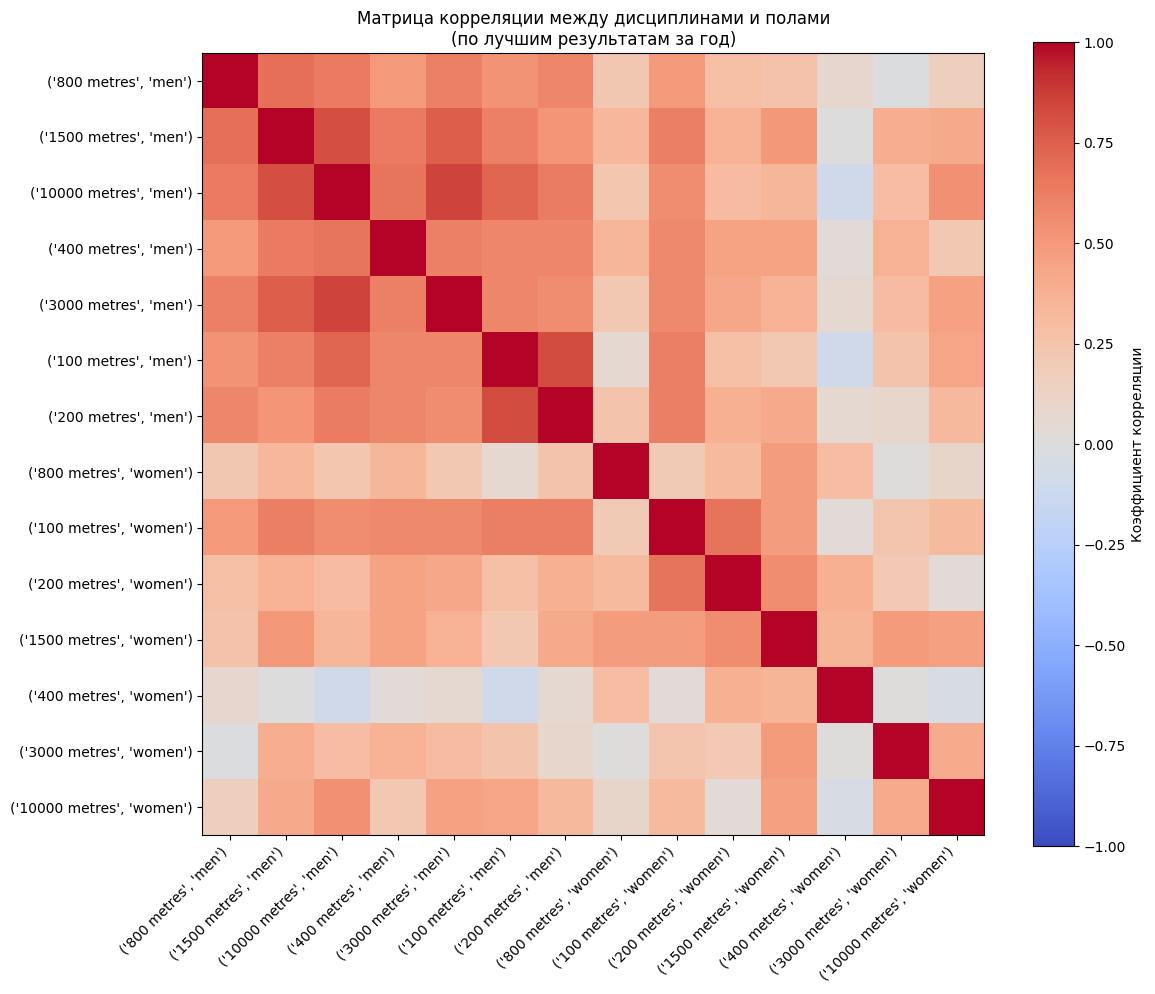

In [31]:
correlation_data = yearly_best.unstack(level=[1, 2])
correlation_matrix = correlation_data.corr()

print("\nМатрица корреляции:")
print(correlation_matrix)

# Визуализация матрицы корреляции
plt.figure(figsize=(12, 10))
plt.imshow(correlation_matrix, cmap='coolwarm', interpolation='none', vmin=-1, vmax=1)
plt.colorbar(label='Коэффициент корреляции')
plt.title('Матрица корреляции между дисциплинами и полами\n(по лучшим результатам за год)')

# Настройка подписей осей
disciplines_genders = correlation_matrix.columns
plt.xticks(range(len(disciplines_genders)), disciplines_genders, rotation=45, ha='right')
plt.yticks(range(len(disciplines_genders)), disciplines_genders)

plt.tight_layout()
plt.show()

Точечная диаграмма

Text(0.5, 1.0, 'Точечная диаграмма: 100 metres vs 200 metres\n(по лучшим результатам за год)')

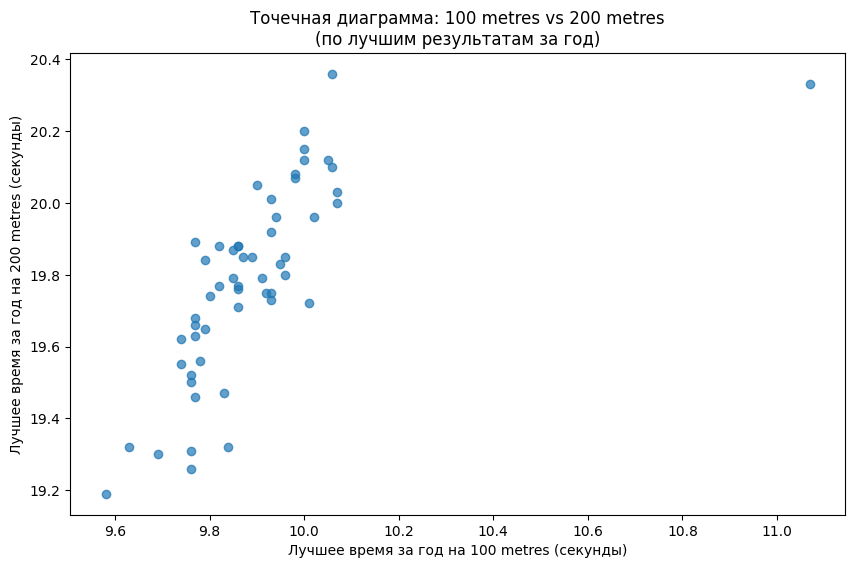

In [ ]:
scatter_df = df_clean.copy()

# Группировка результатов на дистпнциях 100 и 200 метров по году
data_100m = scatter_df[scatter_df['Discipline'] == '100 metres'].groupby('Year')['Time'].min()
data_200m = scatter_df[scatter_df['Discipline'] == '200 metres'].groupby('Year')['Time'].min()

# Объединение в один DataFrame
scatter_data = pd.DataFrame({
    '100 metres': data_100m,
    '200 metres': data_200m
}).dropna()

# Точечная диаграмма
plt.figure(figsize=(10, 6))
plt.scatter(scatter_data['100 metres'], scatter_data['200 metres'], alpha=0.7)
plt.xlabel('Лучшее время за год на 100 metres (секунды)')
plt.ylabel('Лучшее время за год на 200 metres (секунды)')
plt.title('Точечная диаграмма: 100 metres vs 200 metres\n(по лучшим результатам за год)')

### Вывод
Из матрицы корреляции видна достаточно сильная положительная зависимость результата на 100 метров у мужчин от результата на 200 метров (коэффициент корреляции 0,82), что подтверждает гипотезу. Данные результаты можно объяснить тем, что дистанции 100 и 200 метров являются спринтерскими, и, следовательно, при увеличении скорости на одной результат повышается на другой.